# Ariosto League Stats

In [1]:
### INTOCABLE, FECHA 38, GOLERO

import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
import time

# 🚀 Setup del driver
def iniciar_driver():
    chrome_options = Options()
    chrome_options.add_argument("--headless")
    driver = webdriver.Chrome(options=chrome_options)
    return driver

# 🧠 Scraping de un jugador (el arquero)
def scrap_gw_player_info(url):
    driver = iniciar_driver()
    driver.get(url)
    time.sleep(5)  # Esperamos que cargue bien el contenido

    # Encontramos al primer jugador (asumido que es el arquero, top de la cancha)
    try:
        player_button = driver.find_element(By.CSS_SELECTOR, 'button.styles__UnstyledButton-gju4zr-0')

        # Extraer nombre
        player_name = player_button.find_element(By.CLASS_NAME, 'styles__ElementName-sc-52mmxp-5').text.strip()

        # Extraer puntos
        player_points = player_button.find_element(By.CLASS_NAME, 'styles__ElementValue-sc-52mmxp-6').text.strip()

        # Extraer club (desde el src de la camiseta)
        img_tag = player_button.find_element(By.TAG_NAME, 'img')
        shirt_src = img_tag.get_attribute('src')
        team_name = shirt_src.split('/')[-1].split('_')[1]  # e.g., '36' -> Brighton

        driver.quit()
        return {
            "player_name": player_name,
            "points": int(player_points),
            "team_id": team_name,
            "shirt_url": shirt_src
        }

    except Exception as e:
        driver.quit()
        print("❌ Error durante el scraping:", e)
        return None

# 🔍 Ejecutamos
url = "https://draft.premierleague.com/entry/188214/event/38"
resultado = scrap_gw_player_info(url)
print(resultado)


{'player_name': 'Verbruggen', 'points': 2, 'team_id': '36', 'shirt_url': 'https://draft.premierleague.com/img/shirts/standard/shirt_36_1-66.png'}


In [2]:
import pandas as pd
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# Setup Selenium
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")
driver = webdriver.Chrome(options=options)

# Datos de entrada
fantasy_team_name = "Los Intocables"
url_equipo = "https://draft.premierleague.com/entry/188214/event/38"
driver.get(url_equipo)

# Esperar a que cargue la página y hacer click en "List View"
try:
    list_view_btn = WebDriverWait(driver, 10).until(
        EC.element_to_be_clickable((By.LINK_TEXT, "List View"))
    )
    list_view_btn.click()
except:
    print("No se encontró el botón de List View")
    driver.quit()

# Esperar a que aparezcan las filas de jugadores
time.sleep(2)
rows = driver.find_elements(By.XPATH, "//table//tr")

data = []
is_subs_section = False

for row in rows:
    # Chequear si llegamos a la sección de suplentes
    if "Substitutes" in row.text:
        is_subs_section = True
        continue
    
    cols = row.find_elements(By.TAG_NAME, "td")
    if len(cols) < 5:
        continue

    # Datos básicos
    try:
        name = cols[1].text.split("\n")[0]  # Nombre
        team = cols[1].text.split("\n")[1].split()[0]  # Abreviatura del equipo real
        pos = cols[2].text  # Posición
        stats = [c.text for c in cols[3:]]  # Resto de stats
        is_starter = not is_subs_section

        data.append([name, team, pos, fantasy_team_name, is_starter] + stats)
    except:
        continue

# Columnas conocidas (ajustar luego si cambian)
columns = ["Player", "Team", "Position", "Fantasy_team", "Is_starter",
           "MP", "GS", "A", "CS", "GC", "OG", "PS", "PM", "YC", "RC",
           "S", "B", "BPS", "I", "C", "T", "II", "GS2", "EG", "EA", "EGI", "EGC"]

df = pd.DataFrame(data, columns=columns[:len(data[0])])
print(df.head())


       Player    Team Position    Fantasy_team  Is_starter  MP GS  A CS GC  \
0  Verbruggen  BHAGKP      GKP  Los Intocables        True  90  0  0  0  1   
1        Toti  WOLDEF      DEF  Los Intocables        True  90  0  0  0  1   
2     Collins  BREDEF      DEF  Los Intocables        True  90  0  0  0  1   
3      Botman  NEWDEF      DEF  Los Intocables        True  62  0  0  1  0   
4         Eze  CRYMID      MID  Los Intocables        True  61  0  0  1  0   

   ... BPS     I     C   T   II GS2    EG    EA   EGI   EGC  
0  ...   5  12.6     0   0  1.3   1     0     0     0  1.95  
1  ...   8    11   1.7   2  1.5   1     0  0.01  0.01  1.43  
2  ...  11  17.4   0.1   2    2   1     0     0     0  1.12  
3  ...  31  23.4   0.7  74  9.8   1  0.41     0  0.41  0.42  
4  ...  13   5.2  15.2   2  2.2   1     0  0.59  0.59  0.94  

[5 rows x 27 columns]


In [4]:
pd.set_option('display.max_columns', None)\

df.head(18)

,Player,Team,Position,Fantasy_team,Is_starter,MP,GS,A,CS,GC,OG,PS,PM,YC,RC,S,B,BPS,I,C,T,II,GS2,EG,EA,EGI,EGC
0,Verbruggen,BHAGKP,GKP,Los Intocables,True,90,0,0,0,1,0,0,0,0,0,1,0,5,12.6,0,0,1.3,1,0,0,0,1.95
1,Toti,WOLDEF,DEF,Los Intocables,True,90,0,0,0,1,0,0,0,0,0,0,0,8,11,1.7,2,1.5,1,0,0.01,0.01,1.43
2,Collins,BREDEF,DEF,Los Intocables,True,90,0,0,0,1,0,0,0,0,0,0,0,11,17.4,0.1,2,2,1,0,0,0,1.12
3,Botman,NEWDEF,DEF,Los Intocables,True,62,0,0,1,0,0,0,0,0,0,0,0,31,23.4,0.7,74,9.8,1,0.41,0,0.41,0.42
4,Eze,CRYMID,MID,Los Intocables,True,61,0,0,1,0,0,0,0,0,0,0,0,13,5.2,15.2,2,2.2,1,0,0.59,0.59,0.94
5,Bowen,WHUMID,MID,Los Intocables,True,90,1,1,0,1,0,0,0,0,0,0,3,48,64.6,27.7,31,12.3,1,0.12,0.16,0.28,0.79
6,Gibbs-White,NFOMID,MID,Los Intocables,True,90,0,0,0,1,0,0,0,0,0,0,0,10,5.4,6.7,4,1.6,1,0,0.01,0.01,1.07
7,Bruno G.,NEWMID,MID,Los Intocables,True,90,0,0,0,1,0,0,0,0,0,0,0,13,7.8,28.9,11,4.8,1,0.06,0.07,0.13,0.99
8,Gakpo,LIVFWD,FWD,Los Intocables,True,90,0,1,0,1,0,0,0,0,0,0,2,27,23.4,35.6,25,8.4,1,0.06,0.2,0.26,1.75
9,Calvert-Lewin,EVEFWD,FWD,Los Intocables,True,2,0,0,0,0,0,0,0,0,0,0,0,1,2,0,21,2.3,0,0.33,0,0.33,0.32


In [5]:
import pandas as pd
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# Setup Selenium
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")
driver = webdriver.Chrome(options=options)

# Parámetros
fantasy_team_name = "Los Intocables"
gw_number = 38
url_equipo = f"https://draft.premierleague.com/entry/188214/event/{gw_number}"
driver.get(url_equipo)

# Esperar a que cargue la página y hacer click en "List View"
try:
    list_view_btn = WebDriverWait(driver, 10).until(
        EC.element_to_be_clickable((By.LINK_TEXT, "List View"))
    )
    list_view_btn.click()
except:
    print("No se encontró el botón de List View")
    driver.quit()

# Esperar a que aparezcan las filas de jugadores
time.sleep(2)
rows = driver.find_elements(By.XPATH, "//table//tr")

data = []

for row in rows:
    cols = row.find_elements(By.TAG_NAME, "td")
    if len(cols) < 5:
        continue

    try:
        # Datos base
        player_info = cols[1].text.split("\n")
        name = player_info[0].strip()
        team_code = player_info[1][:3].upper()  # Solo las 3 primeras letras
        pos = cols[2].text.strip()
        stats = [c.text for c in cols[3:]]
        data.append([name, team_code, pos, fantasy_team_name] + stats)
    except:
        continue

# Marcar titulares y suplentes
num_players = len(data)
is_starter_list = [True] * (num_players - 4) + [False] * 4  # Asume 11+4

# Añadir columna de jornada y de titulares
for i in range(num_players):
    data[i].insert(4, is_starter_list[i])  # Insertamos Is_starter
    data[i].append(gw_number)              # Añadimos GW

# Columnas
columns = ["Player", "Team", "Position", "Fantasy_team", "Is_starter",
           "MP", "GS", "A", "CS", "GC", "OG", "PS", "PM", "YC", "RC",
           "S", "B", "BPS", "I", "C", "T", "II", "GS2", "EG", "EA", "EGI", "EGC", "GW"]

df = pd.DataFrame(data, columns=columns[:len(data[0])])

# Mostrar todo
pd.set_option('display.max_columns', None)
print(df.head())


       Player Team Position    Fantasy_team  Is_starter  MP GS  A CS GC OG PS  \
0  Verbruggen  BHA      GKP  Los Intocables        True  90  0  0  0  1  0  0   
1        Toti  WOL      DEF  Los Intocables        True  90  0  0  0  1  0  0   
2     Collins  BRE      DEF  Los Intocables        True  90  0  0  0  1  0  0   
3      Botman  NEW      DEF  Los Intocables        True  62  0  0  1  0  0  0   
4         Eze  CRY      MID  Los Intocables        True  61  0  0  1  0  0  0   

  PM YC RC  S  B BPS     I     C   T   II GS2    EG    EA   EGI   EGC  GW  
0  0  0  0  1  0   5  12.6     0   0  1.3   1     0     0     0  1.95  38  
1  0  0  0  0  0   8    11   1.7   2  1.5   1     0  0.01  0.01  1.43  38  
2  0  0  0  0  0  11  17.4   0.1   2    2   1     0     0     0  1.12  38  
3  0  0  0  0  0  31  23.4   0.7  74  9.8   1  0.41     0  0.41  0.42  38  
4  0  0  0  0  0  13   5.2  15.2   2  2.2   1     0  0.59  0.59  0.94  38  


In [7]:
df.head(15)

,Player,Team,Position,Fantasy_team,Is_starter,MP,GS,A,CS,GC,OG,PS,PM,YC,RC,S,B,BPS,I,C,T,II,GS2,EG,EA,EGI,EGC,GW
0,Verbruggen,BHA,GKP,Los Intocables,True,90,0,0,0,1,0,0,0,0,0,1,0,5,12.6,0,0,1.3,1,0,0,0,1.95,38
1,Toti,WOL,DEF,Los Intocables,True,90,0,0,0,1,0,0,0,0,0,0,0,8,11,1.7,2,1.5,1,0,0.01,0.01,1.43,38
2,Collins,BRE,DEF,Los Intocables,True,90,0,0,0,1,0,0,0,0,0,0,0,11,17.4,0.1,2,2,1,0,0,0,1.12,38
3,Botman,NEW,DEF,Los Intocables,True,62,0,0,1,0,0,0,0,0,0,0,0,31,23.4,0.7,74,9.8,1,0.41,0,0.41,0.42,38
4,Eze,CRY,MID,Los Intocables,True,61,0,0,1,0,0,0,0,0,0,0,0,13,5.2,15.2,2,2.2,1,0,0.59,0.59,0.94,38
5,Bowen,WHU,MID,Los Intocables,True,90,1,1,0,1,0,0,0,0,0,0,3,48,64.6,27.7,31,12.3,1,0.12,0.16,0.28,0.79,38
6,Gibbs-White,NFO,MID,Los Intocables,True,90,0,0,0,1,0,0,0,0,0,0,0,10,5.4,6.7,4,1.6,1,0,0.01,0.01,1.07,38
7,Bruno G.,NEW,MID,Los Intocables,True,90,0,0,0,1,0,0,0,0,0,0,0,13,7.8,28.9,11,4.8,1,0.06,0.07,0.13,0.99,38
8,Gakpo,LIV,FWD,Los Intocables,True,90,0,1,0,1,0,0,0,0,0,0,2,27,23.4,35.6,25,8.4,1,0.06,0.2,0.26,1.75,38
9,Calvert-Lewin,EVE,FWD,Los Intocables,True,2,0,0,0,0,0,0,0,0,0,0,0,1,2,0,21,2.3,0,0.33,0,0.33,0.32,38


In [8]:
import pandas as pd
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# Setup Selenium
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")
driver = webdriver.Chrome(options=options)

# Parámetros
fantasy_team_name = "Los Intocables"
entry_id = "188214"
gws = list(range(1, 39))  # GWs de la 1 a la 38

all_data = []

for gw_number in gws:
    url = f"https://draft.premierleague.com/entry/{entry_id}/event/{gw_number}"
    driver.get(url)

    # Intentar acceder a "List View"
    try:
        list_view_btn = WebDriverWait(driver, 5).until(
            EC.element_to_be_clickable((By.LINK_TEXT, "List View"))
        )
        list_view_btn.click()
        time.sleep(2)
    except:
        print(f"List View no disponible en GW {gw_number}, se salta...")
        continue

    # Obtener filas de la tabla
    rows = driver.find_elements(By.XPATH, "//table//tr")
    gw_data = []

    for row in rows:
        cols = row.find_elements(By.TAG_NAME, "td")
        if len(cols) < 5:
            continue

        try:
            player_info = cols[1].text.split("\n")
            name = player_info[0].strip()
            team_code = player_info[1][:3].upper()
            pos = cols[2].text.strip()
            stats = [c.text for c in cols[3:]]
            gw_data.append([name, team_code, pos, fantasy_team_name] + stats)
        except:
            continue

    # Asignar titulares/suplentes
    num_players = len(gw_data)
    is_starter_list = [True] * (num_players - 4) + [False] * 4

    for i in range(num_players):
        gw_data[i].insert(4, is_starter_list[i])  # Is_starter
        gw_data[i].append(gw_number)              # GW

    all_data.extend(gw_data)

# Columnas
columns = ["Player", "Team", "Position", "Fantasy_team", "Is_starter",
           "MP", "GS", "A", "CS", "GC", "OG", "PS", "PM", "YC", "RC",
           "S", "B", "BPS", "I", "C", "T", "II", "GS2", "EG", "EA", "EGI", "EGC", "GW"]

df_participante = pd.DataFrame(all_data, columns=columns[:len(all_data[0])])
pd.set_option('display.max_columns', None)
print(df_participante.head())


      Player Team Position    Fantasy_team  Is_starter  MP GS  A CS GC OG PS  \
0    Flekken  BRE      GKP  Los Intocables        True  90  0  0  0  1  0  0   
1  Tarkowski  EVE      DEF  Los Intocables        True  90  0  0  0  3  0  0   
2     Coufal  WHU      DEF  Los Intocables        True  84  0  0  0  2  0  0   
3    Collins  BRE      DEF  Los Intocables        True  90  0  1  0  1  0  0   
4   Zabarnyi  BOU      DEF  Los Intocables        True  90  0  0  0  1  0  0   

  PM YC RC  S  B BPS     I     C   T   II GS2    EG    EA   EGI   EGC  GW  
0  0  0  0  6  0  22  46.4     0   0  4.6   1     0     0     0  1.17   1  
1  0  1  0  0  0  -4  17.4  10.8   4  3.2   1  0.01  0.01  0.02  1.43   1  
2  0  0  0  0  0  -1    18  15.2   0  3.3   1     0   0.1   0.1  1.96   1  
3  0  0  0  0  1  23  39.4   0.5  17  5.7   1  0.22     0  0.22  1.17   1  
4  0  0  0  0  0   9  15.6   1.1   0  1.7   1     0  0.02  0.02   1.3   1  


In [10]:
df_participante.head(30)

,Player,Team,Position,Fantasy_team,Is_starter,MP,GS,A,CS,GC,OG,PS,PM,YC,RC,S,B,BPS,I,C,T,II,GS2,EG,EA,EGI,EGC,GW
0,Flekken,BRE,GKP,Los Intocables,True,90,0,0,0,1,0,0,0,0,0,6,0,22,46.4,0,0,4.6,1,0,0,0,1.17,1
1,Tarkowski,EVE,DEF,Los Intocables,True,90,0,0,0,3,0,0,0,1,0,0,0,-4,17.4,10.8,4,3.2,1,0.01,0.01,0.02,1.43,1
2,Coufal,WHU,DEF,Los Intocables,True,84,0,0,0,2,0,0,0,0,0,0,0,-1,18,15.2,0,3.3,1,0,0.1,0.1,1.96,1
3,Collins,BRE,DEF,Los Intocables,True,90,0,1,0,1,0,0,0,0,0,0,1,23,39.4,0.5,17,5.7,1,0.22,0,0.22,1.17,1
4,Zabarnyi,BOU,DEF,Los Intocables,True,90,0,0,0,1,0,0,0,0,0,0,0,9,15.6,1.1,0,1.7,1,0,0.02,0.02,1.3,1
5,Eze,CRY,MID,Los Intocables,True,90,0,0,0,2,0,0,0,0,0,0,0,14,12.4,6.8,65,8.4,1,0.41,0.05,0.46,1.59,1
6,Bowen,WHU,MID,Los Intocables,True,72,0,0,0,1,0,0,0,0,0,0,0,3,4.6,16.8,2,2.3,1,0,0.07,0.07,1.76,1
7,Gibbs-White,NFO,MID,Los Intocables,True,90,0,0,0,1,0,0,0,0,0,0,0,8,9.8,41.3,14,6.5,1,0.1,0.07,0.17,1.22,1
8,Bruno G.,NEW,MID,Los Intocables,True,90,0,0,1,0,0,0,0,0,0,0,0,14,21.2,1.8,0,2.3,1,0,0.04,0.04,1.77,1
9,Haaland,MCI,FWD,Los Intocables,True,90,1,0,1,0,0,0,0,1,0,0,2,31,36.4,0.6,38,7.5,1,0.28,0,0.28,1.01,1


In [2]:
import os
import time
import shutil
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# ----------- CONFIGURACIÓN ----------- #

# ID del equipo en Fantasy
entry_id = "188214"
fantasy_team_name = "Los Intocables"
gws = list(range(1, 39))  # GWs 1 a 38

# Ruta del perfil original de Chrome (esto es fijo para Mac)
original_profile_path = "/Users/ignacioferrer/Library/Application Support/Google/Chrome/Default"

# Ruta temporal para clonar el perfil
temp_profile_path = "/Users/ignacioferrer/tmp_chrome_profile"

# Borrar si ya existe y copiar perfil
if os.path.exists(temp_profile_path):
    shutil.rmtree(temp_profile_path)
shutil.copytree(original_profile_path, temp_profile_path)

# ----------- INICIAR CHROME ----------- #

options = webdriver.ChromeOptions()
options.add_argument(f"--user-data-dir={temp_profile_path}")
options.add_argument("--profile-directory=Default")
options.add_argument("--start-maximized")
driver = webdriver.Chrome(options=options)

# ----------- SCRAPING ----------- #

all_data = []

for gw_number in gws:
    url = f"https://draft.premierleague.com/entry/{entry_id}/event/{gw_number}"
    driver.get(url)

    # Intentar acceder a "List View"
    try:
        list_view_btn = WebDriverWait(driver, 5).until(
            EC.element_to_be_clickable((By.LINK_TEXT, "List View"))
        )
        list_view_btn.click()
        time.sleep(2)
    except:
        print(f"List View no disponible en GW {gw_number}, se salta...")
        continue

    # Obtener filas de la tabla
    rows = driver.find_elements(By.XPATH, "//table//tr")
    gw_data = []

    for row in rows:
        cols = row.find_elements(By.TAG_NAME, "td")
        if len(cols) < 5:
            continue

        try:
            player_info = cols[1].text.split("\n")
            name = player_info[0].strip()
            team_code = player_info[1][:3].upper()  # solo 3 letras del equipo
            pos = cols[2].text.strip()
            stats = [c.text for c in cols[3:]]
            gw_data.append([name, team_code, pos, fantasy_team_name] + stats)
        except:
            continue

    # Marcar titulares y suplentes
    num_players = len(gw_data)
    is_starter_list = [True] * (num_players - 4) + [False] * 4

    for i in range(num_players):
        gw_data[i].insert(4, is_starter_list[i])  # is_starter
        gw_data[i].append(gw_number)              # GW

    all_data.extend(gw_data)

# ----------- CREAR DATAFRAME ----------- #

columns = ["Player", "Team", "Position", "Fantasy_team", "Is_starter",
           "MP", "GS", "A", "CS", "GC", "OG", "PS", "PM", "YC", "RC",
           "S", "B", "BPS", "I", "C", "T", "II", "GS2", "EG", "EA", "EGI", "EGC", "GW"]

df_participante = pd.DataFrame(all_data, columns=columns[:len(all_data[0])])
pd.set_option('display.max_columns', None)

# ----------- MOSTRAR RESULTADO ----------- #

print(df_participante.head())

# ----------- CERRAR ----------- #
driver.quit()


      Player Team Position    Fantasy_team  Is_starter  MP GS  A CS GC OG PS  \
0    Flekken  BRE      GKP  Los Intocables        True  90  0  0  0  1  0  0   
1  Tarkowski  EVE      DEF  Los Intocables        True  90  0  0  0  3  0  0   
2     Coufal  WHU      DEF  Los Intocables        True  84  0  0  0  2  0  0   
3    Collins  BRE      DEF  Los Intocables        True  90  0  1  0  1  0  0   
4   Zabarnyi  BOU      DEF  Los Intocables        True  90  0  0  0  1  0  0   

  PM YC RC  S  B BPS     I     C   T   II GS2    EG    EA   EGI   EGC  GW  
0  0  0  0  6  0  22  46.4     0   0  4.6   1     0     0     0  1.17   1  
1  0  1  0  0  0  -4  17.4  10.8   4  3.2   1  0.01  0.01  0.02  1.43   1  
2  0  0  0  0  0  -1    18  15.2   0  3.3   1     0   0.1   0.1  1.96   1  
3  0  0  0  0  1  23  39.4   0.5  17  5.7   1  0.22     0  0.22  1.17   1  
4  0  0  0  0  0   9  15.6   1.1   0  1.7   1     0  0.02  0.02   1.3   1  


In [3]:
import os
import time
import shutil
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# --- CONFIGURACIÓN DE PERFIL CLONADO ---
original_profile_path = "/Users/ignacioferrer/Library/Application Support/Google/Chrome/Default"
temp_profile_path = "/Users/ignacioferrer/tmp_chrome_profile"
if os.path.exists(temp_profile_path):
    shutil.rmtree(temp_profile_path)
shutil.copytree(original_profile_path, temp_profile_path)

# --- URLs de los equipos ---
urls = [
    "https://draft.premierleague.com/entry/223347/event/38",
    "https://draft.premierleague.com/entry/103729/event/38",
    "https://draft.premierleague.com/entry/103758/event/38",
    "https://draft.premierleague.com/entry/189672/event/38",
    "https://draft.premierleague.com/entry/198262/event/38",
    "https://draft.premierleague.com/entry/103759/event/38",
    "https://draft.premierleague.com/entry/103774/event/38",
    "https://draft.premierleague.com/entry/103768/event/38",
    "https://draft.premierleague.com/entry/115212/event/38",
    "https://draft.premierleague.com/entry/118206/event/38",
    "https://draft.premierleague.com/entry/103750/event/38",
]

options = webdriver.ChromeOptions()
options.add_argument(f"--user-data-dir={temp_profile_path}")
options.add_argument("--profile-directory=Default")
options.add_argument("--start-maximized")
driver = webdriver.Chrome(options=options)

os.makedirs("data/fpl/participantes", exist_ok=True)
gws = list(range(1, 39))

for url in urls:
    driver.get(url)
    time.sleep(2)
    
    # Extraer entry_id y nombre del equipo Fantasy
    entry_id = url.split("/entry/")[1].split("/")[0]
    try:
        team_name = WebDriverWait(driver,5).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, "strong"))
        ).text.strip()
    except:
        team_name = f"team_{entry_id}"
    safe_name = team_name.replace(" ", "_")
    all_data = []
    
    for gw in gws:
        gw_url = f"https://draft.premierleague.com/entry/{entry_id}/event/{gw}"
        driver.get(gw_url)
        try:
            WebDriverWait(driver,5).until(
                EC.element_to_be_clickable((By.LINK_TEXT, "List View"))
            ).click()
            time.sleep(2)
        except:
            continue
        
        rows = driver.find_elements(By.XPATH, "//table//tr")
        for row in rows:
            cols = row.find_elements(By.TAG_NAME, "td")
            if len(cols) < 5: continue
            try:
                info = cols[1].text.split("\n")
                name = info[0]
                code = info[1][:3].upper()
                pos = cols[2].text
                stats = [c.text for c in cols[3:]]
                all_data.append([name, code, pos, team_name] + stats + [gw])
            except:
                continue
    
    if all_data:
        columns = ["Player", "Team", "Position", "Fantasy_team", "MP", "GS", "A",
                   "CS", "GC", "OG", "PS", "PM", "YC", "RC", "S", "B", "BPS",
                   "I", "C", "T", "II", "GS2", "EG", "EA", "EGI", "EGC", "GW"]
        df = pd.DataFrame(all_data, columns=columns[:len(all_data[0])])
        df.to_csv(f"data/fpl/participantes/{safe_name}.csv", index=False)
        print(f"✅ Guardado: {safe_name}.csv")
    else:
        print(f"⚠️ Sin datos para: {safe_name}")

driver.quit()



✅ Guardado: local_time.csv


ProtocolError: ('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer'))

In [4]:
import os
import time
import shutil
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# Configuración de perfil clonado
original_profile_path = "/Users/ignacioferrer/Library/Application Support/Google/Chrome/Default"
temp_profile_path = "/Users/ignacioferrer/tmp_chrome_profile"
if os.path.exists(temp_profile_path):
    shutil.rmtree(temp_profile_path)
shutil.copytree(original_profile_path, temp_profile_path)

# URLs de equipos Fantasy
urls = [
    "https://draft.premierleague.com/entry/223347/event/38",
    "https://draft.premierleague.com/entry/103729/event/38",
    "https://draft.premierleague.com/entry/103758/event/38",
    "https://draft.premierleague.com/entry/189672/event/38",
    "https://draft.premierleague.com/entry/198262/event/38",
    "https://draft.premierleague.com/entry/103759/event/38",
    "https://draft.premierleague.com/entry/103774/event/38",
    "https://draft.premierleague.com/entry/103768/event/38",
    "https://draft.premierleague.com/entry/115212/event/38",
    "https://draft.premierleague.com/entry/118206/event/38",
    "https://draft.premierleague.com/entry/103750/event/38",
]

# Selenium config
options = webdriver.ChromeOptions()
options.add_argument(f"--user-data-dir={temp_profile_path}")
options.add_argument("--profile-directory=Default")
options.add_argument("--start-maximized")
driver = webdriver.Chrome(options=options)

gws = list(range(1, 39))
os.makedirs("data/fpl/participantes", exist_ok=True)

for url in urls:
    driver.get(url)
    time.sleep(2)
    
    # Extraer entry_id y nombre real
    entry_id = url.split("/entry/")[1].split("/")[0]
    try:
        title = WebDriverWait(driver, 5).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, "h2.Title-r2vo7u-0"))
        ).text
        fantasy_team_name = title.split("Points - ")[1].strip()
    except:
        fantasy_team_name = f"team_{entry_id}"
    
    print(f"🧠 Procesando equipo: {fantasy_team_name}")
    safe_name = fantasy_team_name.replace(" ", "_")
    all_data = []

    for gw in gws:
        gw_url = f"https://draft.premierleague.com/entry/{entry_id}/event/{gw}"
        driver.get(gw_url)

        try:
            WebDriverWait(driver, 5).until(
                EC.element_to_be_clickable((By.LINK_TEXT, "List View"))
            ).click()
            time.sleep(2)
        except:
            continue

        rows = driver.find_elements(By.XPATH, "//table//tr")
        gw_data = []

        for row in rows:
            cols = row.find_elements(By.TAG_NAME, "td")
            if len(cols) < 5:
                continue
            try:
                player_info = cols[1].text.split("\n")
                name = player_info[0].strip()
                team_code = player_info[1][:3].upper()
                pos = cols[2].text.strip()
                stats = [c.text for c in cols[3:]]
                gw_data.append([name, team_code, pos, fantasy_team_name] + stats)
            except:
                continue

        # Agregar Is_starter y GW
        num_players = len(gw_data)
        is_starter_list = [True] * (num_players - 4) + [False] * 4
        for i in range(num_players):
            gw_data[i].insert(4, is_starter_list[i])  # Is_starter
            gw_data[i].append(gw)  # Jornada
        all_data.extend(gw_data)

    if all_data:
        columns = ["Player", "Team", "Position", "Fantasy_team", "Is_starter",
                   "MP", "GS", "A", "CS", "GC", "OG", "PS", "PM", "YC", "RC",
                   "S", "B", "BPS", "I", "C", "T", "II", "GS2", "EG", "EA", "EGI", "EGC", "GW"]
        df = pd.DataFrame(all_data, columns=columns[:len(all_data[0])])
        df.to_csv(f"data/fpl/participantes/{safe_name}.csv", index=False)
        print(f"✅ Guardado: {safe_name}.csv")
    else:
        print(f"⚠️ Sin datos para: {fantasy_team_name}")

driver.quit()


🧠 Procesando equipo: Mi Bebito siu siu .3
✅ Guardado: Mi_Bebito_siu_siu_.3.csv
🧠 Procesando equipo: Marculis ⭐️
✅ Guardado: Marculis_⭐️.csv
🧠 Procesando equipo: MrCanter
✅ Guardado: MrCanter.csv
🧠 Procesando equipo: Los manolotos
✅ Guardado: Los_manolotos.csv
🧠 Procesando equipo: Jagger Athletic
✅ Guardado: Jagger_Athletic.csv
🧠 Procesando equipo: Wawrinka F.C.
✅ Guardado: Wawrinka_F.C..csv
🧠 Procesando equipo: Ignagol
✅ Guardado: Ignagol.csv
🧠 Procesando equipo: Papezared ⭐️
✅ Guardado: Papezared_⭐️.csv
🧠 Procesando equipo: Los Santiagueños ⭐️
✅ Guardado: Los_Santiagueños_⭐️.csv
🧠 Procesando equipo: Comandantes
✅ Guardado: Comandantes.csv
🧠 Procesando equipo: Varela Futbol Club
✅ Guardado: Varela_Futbol_Club.csv


In [5]:
df.head()

,Player,Team,Position,Fantasy_team,Is_starter,MP,GS,A,CS,GC,OG,PS,PM,YC,RC,S,B,BPS,I,C,T,II,GS2,EG,EA,EGI,EGC,GW
0,Onana,MUN,GKP,Varela Futbol Club,True,90,0,0,1,0,0,0,0,0,0,2,0,25,16.8,0,0,1.7,1,0,0,0,0.44,1
1,Rúben,MCI,DEF,Varela Futbol Club,True,90,0,0,1,0,0,0,0,0,0,0,0,27,14.2,0.5,0,1.5,1,0,0,0,1.01,1
2,Udogie,TOT,DEF,Varela Futbol Club,True,90,0,0,0,1,0,0,0,0,0,0,0,2,15.6,7.8,10,3.3,1,0,0.06,0.06,1.02,1
3,Konaté,LIV,DEF,Varela Futbol Club,True,45,0,0,0,0,0,0,0,0,0,0,0,12,14.2,0.3,0,1.5,0,0,0,0,0.15,1
4,Cucurella,CHE,DEF,Varela Futbol Club,True,79,0,0,0,1,0,0,0,0,0,0,0,16,18,4,2,2.4,1,0,0.02,0.02,0.69,1


In [7]:
import pandas as pd
import os

# Ruta a la carpeta que contiene todos los CSVs
ruta_csvs = "/Users/ignacioferrer/UE - Python/Ariosto League/data/fpl/participantes"

# Listar todos los archivos CSV en la carpeta
archivos_csv = [f for f in os.listdir(ruta_csvs) if f.endswith(".csv")]

# Cargar cada CSV y añadirlo a una lista de DataFrames
dfs = []
for archivo in archivos_csv:
    path_completo = os.path.join(ruta_csvs, archivo)
    try:
        df = pd.read_csv(path_completo)
        dfs.append(df)
    except Exception as e:
        print(f"⚠️ Error al cargar {archivo}: {e}")

# Concatenar todos los DataFrames
if dfs:
    df_master = pd.concat(dfs, ignore_index=True)
    pd.set_option('display.max_columns', None)
    print(df_master.head())
else:
    print("❌ No se cargó ningún archivo CSV.")


        Player Team Position   Fantasy_team  Is_starter  MP  GS  A  CS  GC  \
0         Raya  ARS      GKP  Los manolotos        True  90   0  0   1   0   
1  Pedro Porro  TOT      DEF  Los manolotos        True  90   1  0   0   1   
2        Muñoz  CRY      DEF  Los manolotos        True  90   0  1   0   2   
3         Dunk  BHA      DEF  Los manolotos        True  75   0  0   1   0   
4      Pinnock  BRE      DEF  Los manolotos        True  90   0  0   0   1   

   OG  PS  PM  YC  RC  S  B  BPS     I     C   T    II  GS2    EG    EA   EGI  \
0   0   0   0   0   0  3  1   28  28.0   0.0   0   2.8    1  0.00  0.00  0.00   
1   0   0   0   0   0  0  1   28  50.0  59.3  21  13.0    1  0.09  0.32  0.41   
2   0   0   0   0   0  0  0   11  12.2  13.4   6   3.2    1  0.00  0.02  0.02   
3   0   0   0   0   0  0  0   23   7.0   0.3   6   1.3    1  0.07  0.00  0.07   
4   1   0   0   0   0  0  0    3  18.8   0.1  17   3.6    1  0.01  0.00  0.01   

    EGC  GW  
0  0.47   1  
1  0.96   1  
2 

In [10]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6270 entries, 0 to 6269
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Player        6270 non-null   object 
 1   Team          6270 non-null   object 
 2   Position      6270 non-null   object 
 3   Fantasy_team  6270 non-null   object 
 4   Is_starter    6270 non-null   bool   
 5   MP            6270 non-null   int64  
 6   GS            6270 non-null   int64  
 7   A             6270 non-null   int64  
 8   CS            6270 non-null   int64  
 9   GC            6270 non-null   int64  
 10  OG            6270 non-null   int64  
 11  PS            6270 non-null   int64  
 12  PM            6270 non-null   int64  
 13  YC            6270 non-null   int64  
 14  RC            6270 non-null   int64  
 15  S             6270 non-null   int64  
 16  B             6270 non-null   int64  
 17  BPS           6270 non-null   int64  
 18  I             6270 non-null 

In [11]:
# Convertir columnas numéricas que pueden haber llegado como texto
columnas_numericas = ["MP", "BPS", "I", "C", "T", "II", "GW"]
df_master[columnas_numericas] = df_master[columnas_numericas].apply(pd.to_numeric, errors="coerce")

# Agrupar por jugador y equipo real
df_jugadores = df_master.groupby(["Player", "Team", "Position"]).agg(
    total_puntos=("BPS", "sum"),
    total_II=("II", "sum"),
    partidos_jugados=("MP", lambda x: (x > 0).sum()),
    minutos_totales=("MP", "sum"),
    equipos_fantasy_distintos=("Fantasy_team", lambda x: x.nunique())
).reset_index()

# Agregar promedios
df_jugadores["promedio_puntos"] = df_jugadores["total_puntos"] / df_jugadores["partidos_jugados"]
df_jugadores["promedio_II"] = df_jugadores["total_II"] / df_jugadores["partidos_jugados"]

# Mostrar
pd.set_option('display.max_columns', None)
df_jugadores = df_jugadores.sort_values("total_puntos", ascending=False)
df_jugadores.head(10)


,Player,Team,Position,total_puntos,total_II,partidos_jugados,minutos_totales,equipos_fantasy_distintos,promedio_puntos,promedio_II
179,M.Salah,LIV,MID,1133,476.0,36,3374,1,31.472222,13.222222
239,Palmer,CHE,MID,952,337.4,37,3193,1,25.729730,9.118919
200,Mbeumo,BRE,MID,948,340.8,38,3415,1,24.947368,8.968421
130,Isak,NEW,FWD,848,292.7,33,2758,1,25.696970,8.869697
59,Cunha,WOL,FWD,838,272.3,33,2596,1,25.393939,8.251515
25,B.Fernandes,MUN,MID,810,300.8,36,3017,1,22.500000,8.355556
332,Wood,NFO,FWD,744,205.5,36,2958,1,20.666667,5.708333
331,Wissa,BRE,FWD,739,242.4,35,2921,1,21.114286,6.925714
131,Iwobi,FUL,MID,704,243.0,38,2981,1,18.526316,6.394737
176,Luis Díaz,LIV,MID,634,246.4,34,2393,1,18.647059,7.247059


In [12]:
import pandas as pd

# Asegurarse de que estas columnas son numéricas
df_master[["MP", "BPS", "I", "C", "T", "II"]] = df_master[["MP", "BPS", "I", "C", "T", "II"]].apply(pd.to_numeric, errors="coerce")

# Agrupar por jugador, equipo y posición
df_jugadores = df_master.groupby(["Player", "Team", "Position"]).agg(
    total_puntos=("BPS", "sum"),
    total_II=("II", "sum"),
    partidos_jugados=("MP", lambda x: (x > 0).sum()),
    minutos=("MP", "sum"),
    equipos_fantasy=("Fantasy_team", "nunique")
).reset_index()

# Promedios por partido
df_jugadores["promedio_puntos"] = df_jugadores["total_puntos"] / df_jugadores["partidos_jugados"]
df_jugadores["promedio_II"] = df_jugadores["total_II"] / df_jugadores["partidos_jugados"]

# Rankings
df_jugadores["rank_total_puntos"] = df_jugadores["total_puntos"].rank(ascending=False).astype(int)
df_jugadores["rank_total_II"] = df_jugadores["total_II"].rank(ascending=False).astype(int)

# Top 20 por posición
top20_por_posicion = {}
for pos in df_jugadores["Position"].unique():
    top20 = df_jugadores[df_jugadores["Position"] == pos] \
        .sort_values(["promedio_puntos", "promedio_II"], ascending=False) \
        .head(20)
    top20_por_posicion[pos] = top20

# Mostrar el resumen general
pd.set_option('display.max_columns', None)
display(df_jugadores.sort_values("rank_total_puntos").head(30))  # Top 30 jugadores en puntos totales


,Player,Team,Position,total_puntos,total_II,partidos_jugados,minutos,equipos_fantasy,promedio_puntos,promedio_II,rank_total_puntos,rank_total_II
179,M.Salah,LIV,MID,1133,476.0,36,3374,1,31.472222,13.222222,1,1
239,Palmer,CHE,MID,952,337.4,37,3193,1,25.729730,9.118919,2,3
200,Mbeumo,BRE,MID,948,340.8,38,3415,1,24.947368,8.968421,3,2
130,Isak,NEW,FWD,848,292.7,33,2758,1,25.696970,8.869697,4,5
59,Cunha,WOL,FWD,838,272.3,33,2596,1,25.393939,8.251515,5,6
25,B.Fernandes,MUN,MID,810,300.8,36,3017,1,22.500000,8.355556,6,4
332,Wood,NFO,FWD,744,205.5,36,2958,1,20.666667,5.708333,7,18
331,Wissa,BRE,FWD,739,242.4,35,2921,1,21.114286,6.925714,8,10
131,Iwobi,FUL,MID,704,243.0,38,2981,1,18.526316,6.394737,9,9
176,Luis Díaz,LIV,MID,634,246.4,34,2393,1,18.647059,7.247059,10,8


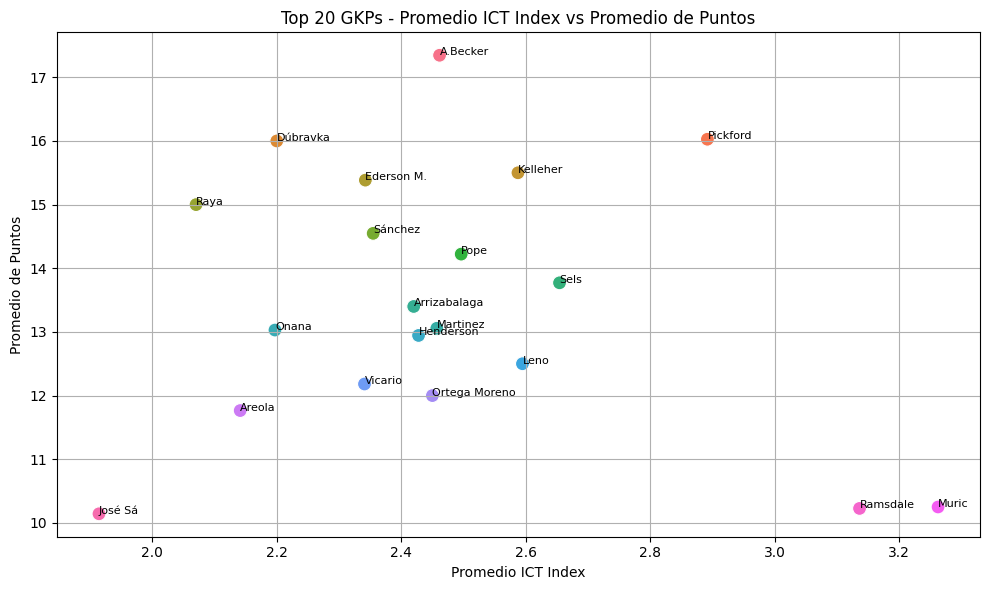

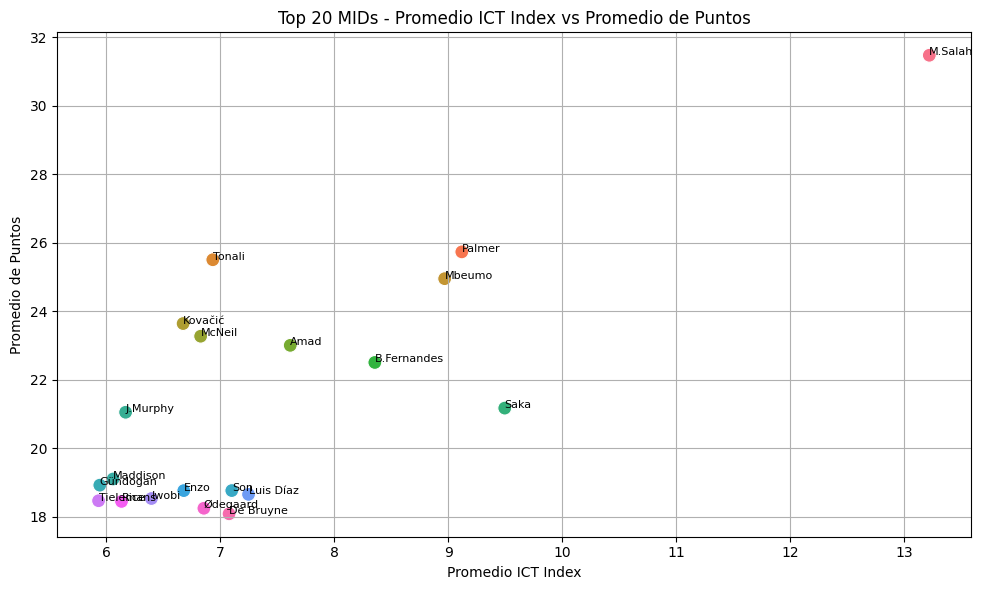

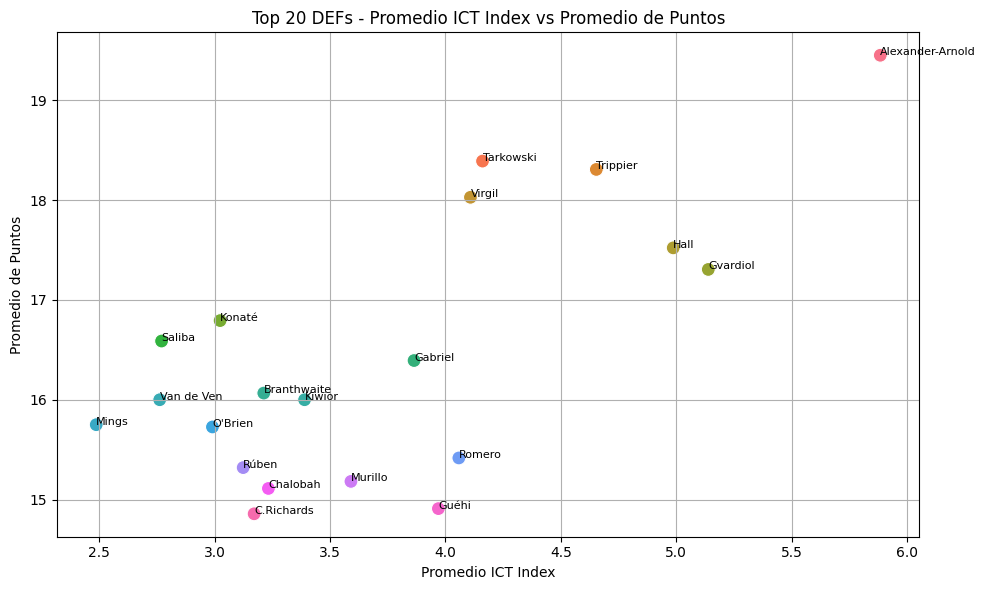

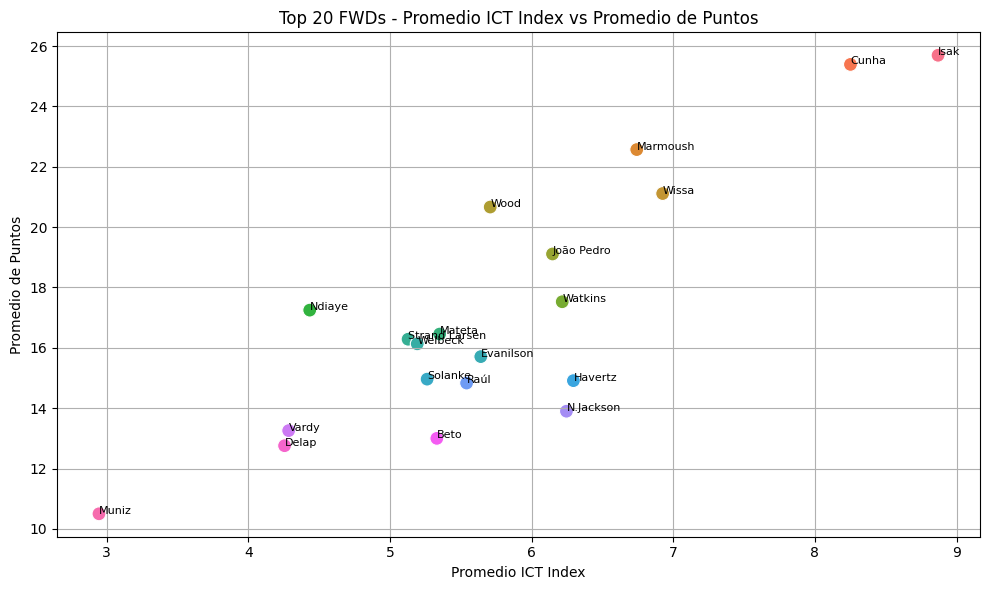

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar tipos numéricos
df_master[["MP", "BPS", "I", "C", "T", "II"]] = df_master[["MP", "BPS", "I", "C", "T", "II"]].apply(pd.to_numeric, errors="coerce")

# Agrupación por jugador, equipo y posición
df_jugadores = df_master.groupby(["Player", "Team", "Position"]).agg(
    total_puntos=("BPS", "sum"),
    total_II=("II", "sum"),
    partidos_jugados=("MP", lambda x: (x > 0).sum()),
    minutos=("MP", "sum"),
    equipos_fantasy=("Fantasy_team", "nunique")
).reset_index()

# Calcular promedios
df_jugadores["promedio_puntos"] = df_jugadores["total_puntos"] / df_jugadores["partidos_jugados"]
df_jugadores["promedio_II"] = df_jugadores["total_II"] / df_jugadores["partidos_jugados"]

# Ranking general
df_jugadores["rank_total_puntos"] = df_jugadores["total_puntos"].rank(ascending=False).astype(int)
df_jugadores["rank_total_II"] = df_jugadores["total_II"].rank(ascending=False).astype(int)

# Filtrar jugadores con mínimo de partidos
df_filtrado = df_jugadores[df_jugadores["partidos_jugados"] >= 5]

# Mostrar los 20 mejores por posición
top20_por_posicion = {}
for pos in df_filtrado["Position"].unique():
    top20 = df_filtrado[df_filtrado["Position"] == pos] \
        .sort_values(["promedio_puntos", "promedio_II"], ascending=False) \
        .head(20)
    top20_por_posicion[pos] = top20

# Visualización por posición
for pos, df_pos in top20_por_posicion.items():
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_pos,
        x="promedio_II",
        y="promedio_puntos",
        hue="Player",
        s=100,
        legend=False
    )
    for _, row in df_pos.iterrows():
        plt.text(row["promedio_II"], row["promedio_puntos"], row["Player"], fontsize=8)
    plt.title(f"Top 20 {pos}s - Promedio ICT Index vs Promedio de Puntos")
    plt.xlabel("Promedio ICT Index")
    plt.ylabel("Promedio de Puntos")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [22]:
# Agrupar jugadores únicos por posición
df_draft = df_master.groupby(['Player', 'Position']).agg({
    'Fantasy_team': 'nunique',        # Cantidad de equipos en los que estuvo
    'MP': 'sum',
    'BPS': 'sum',
    'I': 'sum',
    'C': 'sum',
    'T': 'sum',
    'II': 'sum',
    'GS': 'sum',
    'A': 'sum',
    'B': 'sum',
    'EGI': 'sum',                     # Expected Goals Involvement
    'GW': 'count',                    # Partidos jugados (jornadas)
}).reset_index()

# Calcular promedios
df_draft['II_per_game'] = df_draft['II'] / df_draft['GW']
df_draft['EGI_per_game'] = df_draft['EGI'] / df_draft['GW']
df_draft['In_teams'] = df_draft['Fantasy_team']

# Ordenar por posición y productividad
df_draft = df_draft.sort_values(by=['Position', 'II_per_game'], ascending=[True, False])


In [24]:
df_draft.head()

,Player,Position,Fantasy_team,MP,BPS,I,C,T,II,GS,A,B,EGI,GW,II_per_game,EGI_per_game,In_teams
6,Agbadou,DEF,1,180,43,60.2,42.3,13,11.5,0,0,0,0.37,2,5.750000,0.185000,1
275,Sessegnon,DEF,1,388,73,143.2,111.2,116,37.2,1,1,5,1.43,7,5.314286,0.204286,1
214,Muñoz,DEF,1,3229,480,816.6,634.2,524,197.6,4,6,9,8.38,38,5.200000,0.220526,1
243,Pedro Porro,DEF,1,2606,456,778.4,932.9,200,191.2,2,6,6,6.34,38,5.031579,0.166842,1
24,Aït-Nouri,DEF,1,3112,447,773.2,694.0,435,190.5,4,7,13,6.67,38,5.013158,0.175526,1


In [28]:

# Asegurarse de que MP esté bien
df_master["MP"] = pd.to_numeric(df_master["MP"], errors="coerce").fillna(0)

# Agrupar info útil para draft
df_draft = df_master.groupby(['Player', 'Position']).agg({
    'Fantasy_team': 'nunique',        # Cantidad de equipos en los que estuvo
    'MP': 'sum',
    'BPS': 'sum',
    'I': 'sum',
    'C': 'sum',
    'T': 'sum',
    'II': 'sum',
    'GS': 'sum',
    'A': 'sum',
    'B': 'sum',
    'EGI': 'sum',
    'GW': 'count',
}).reset_index()

# Métricas adicionales
df_draft['Matches_played'] = df_draft['MP'] / 90
df_draft['II_per_game'] = df_draft['II'] / df_draft['Matches_played']
df_draft['EGI_per_game'] = df_draft['EGI'] / df_draft['Matches_played']
df_draft['In_teams'] = df_draft['Fantasy_team']

# Ordenar por posición y productividad
df_draft = df_draft.sort_values(by=['Position', 'II_per_game'], ascending=[True, False])

In [29]:
df_draft.head()

,Player,Position,Fantasy_team,MP,BPS,I,C,T,II,GS,A,B,EGI,GW,Matches_played,II_per_game,EGI_per_game,In_teams
263,S.Bueno,DEF,1,6,5,7.6,0.3,0,0.8,0,0,0,0.00,1,0.066667,12.000000,0.000000,1
275,Sessegnon,DEF,1,388,73,143.2,111.2,116,37.2,1,1,5,1.43,7,4.311111,8.628866,0.331701,1
306,Tsimikas,DEF,3,310,58,87.0,137.6,23,24.8,0,0,1,1.01,8,3.444444,7.200000,0.293226,3
12,Alexander-Arnold,DEF,1,2362,603,723.8,833.7,268,182.4,3,7,13,9.01,38,26.244444,6.950042,0.343311,1
243,Pedro Porro,DEF,1,2606,456,778.4,932.9,200,191.2,2,6,6,6.34,38,28.955556,6.603223,0.218956,1


In [30]:
import pandas as pd

# Agrupar y ordenar por posición
top_players_by_position = []

for position in df_draft['Position'].unique():
    top_30 = (
        df_draft[df_draft['Position'] == position]
        .sort_values(by='II_per_game', ascending=False)
        .head(30)
    )
    top_30['Posición'] = position  # agregamos la columna explícita por si se pierde
    top_players_by_position.append(top_30)

# Concatenar todo en un único DataFrame
df_top_30 = pd.concat(top_players_by_position, ignore_index=True)

# Mostrar las primeras filas para revisar
print(df_top_30.head())

# Si querés exportarlo a CSV:
#df_top_30.to_csv('/Users/ignacioferrer/UE - Python/Ariosto League/data/fpl/top_30_por_posicion.csv', index=False)


             Player Position  Fantasy_team    MP  BPS      I      C    T  \
0           S.Bueno      DEF             1     6    5    7.6    0.3    0   
1         Sessegnon      DEF             1   388   73  143.2  111.2  116   
2          Tsimikas      DEF             3   310   58   87.0  137.6   23   
3  Alexander-Arnold      DEF             1  2362  603  723.8  833.7  268   
4       Pedro Porro      DEF             1  2606  456  778.4  932.9  200   

      II  GS  A   B   EGI  GW  Matches_played  II_per_game  EGI_per_game  \
0    0.8   0  0   0  0.00   1        0.066667    12.000000      0.000000   
1   37.2   1  1   5  1.43   7        4.311111     8.628866      0.331701   
2   24.8   0  0   1  1.01   8        3.444444     7.200000      0.293226   
3  182.4   3  7  13  9.01  38       26.244444     6.950042      0.343311   
4  191.2   2  6   6  6.34  38       28.955556     6.603223      0.218956   

   In_teams Posición  
0         1      DEF  
1         1      DEF  
2         3      

In [32]:
df_top_30.head(50)

,Player,Position,Fantasy_team,MP,BPS,I,C,T,II,GS,A,B,EGI,GW,Matches_played,II_per_game,EGI_per_game,In_teams,Posición
0,S.Bueno,DEF,1,6,5,7.6,0.3,0,0.8,0,0,0,0.00,1,0.066667,12.000000,0.000000,1,DEF
1,Sessegnon,DEF,1,388,73,143.2,111.2,116,37.2,1,1,5,1.43,7,4.311111,8.628866,0.331701,1,DEF
2,Tsimikas,DEF,3,310,58,87.0,137.6,23,24.8,0,0,1,1.01,8,3.444444,7.200000,0.293226,3,DEF
3,Alexander-Arnold,DEF,1,2362,603,723.8,833.7,268,182.4,3,7,13,9.01,38,26.244444,6.950042,0.343311,1,DEF
4,Pedro Porro,DEF,1,2606,456,778.4,932.9,200,191.2,2,6,6,6.34,38,28.955556,6.603223,0.218956,1,DEF
5,Agbadou,DEF,1,180,43,60.2,42.3,13,11.5,0,0,0,0.37,2,2.000000,5.750000,0.185000,1,DEF
6,F.Kadıoğlu,DEF,1,385,59,116.4,83.7,40,24.0,1,0,0,0.75,15,4.277778,5.610390,0.175325,1,DEF
7,Aït-Nouri,DEF,1,3112,447,773.2,694.0,435,190.5,4,7,13,6.67,38,34.577778,5.509319,0.192898,1,DEF
8,Muñoz,DEF,1,3229,480,816.6,634.2,524,197.6,4,6,9,8.38,38,35.877778,5.507587,0.233571,1,DEF
9,Bradley,DEF,3,322,34,70.6,37.2,88,19.5,0,1,0,1.53,8,3.577778,5.450311,0.427640,3,DEF


In [33]:
# Filtrar jugadores con al menos 5 partidos jugados (450 minutos)
df_draft_filtrado = df_draft[df_draft['Matches_played'] >= 5]

# Luego hacés el top 30 como antes:
top_players_by_position = []

for position in df_draft_filtrado['Position'].unique():
    top_30 = (
        df_draft_filtrado[df_draft_filtrado['Position'] == position]
        .sort_values(by='II_per_game', ascending=False)
        .head(30)
    )
    top_30['Posición'] = position
    top_players_by_position.append(top_30)

df_top_30_filtrado = pd.concat(top_players_by_position, ignore_index=True)


In [34]:
df_top_30_filtrado.head(60)

,Player,Position,Fantasy_team,MP,BPS,I,C,T,II,GS,A,B,EGI,GW,Matches_played,II_per_game,EGI_per_game,In_teams,Posición
0,Alexander-Arnold,DEF,1,2362,603,723.8,833.7,268,182.4,3,7,13,9.01,38,26.244444,6.950042,0.343311,1,DEF
1,Pedro Porro,DEF,1,2606,456,778.4,932.9,200,191.2,2,6,6,6.34,38,28.955556,6.603223,0.218956,1,DEF
2,Aït-Nouri,DEF,1,3112,447,773.2,694.0,435,190.5,4,7,13,6.67,38,34.577778,5.509319,0.192898,1,DEF
3,Muñoz,DEF,1,3229,480,816.6,634.2,524,197.6,4,6,9,8.38,38,35.877778,5.507587,0.233571,1,DEF
4,Trippier,DEF,3,1009,238,261.8,314.8,28,60.5,0,3,8,1.18,18,11.211111,5.396432,0.105253,3,DEF
5,Hall,DEF,1,1941,403,505.4,514.4,126,114.7,0,7,11,3.99,23,21.566667,5.318393,0.185008,1,DEF
6,Robinson,DEF,1,3166,507,922.2,723.4,206,185.5,0,10,8,4.87,38,35.177778,5.273215,0.138440,1,DEF
7,Calafiori,DEF,3,921,133,249.6,116.2,174,53.9,2,1,1,1.54,28,10.233333,5.267101,0.150489,3,DEF
8,Gvardiol,DEF,1,3278,623,846.8,501.7,497,185.0,5,0,15,7.52,38,36.422222,5.079317,0.206467,1,DEF
9,Digne,DEF,3,2258,360,492.4,568.0,112,117.1,0,5,7,4.66,35,25.088889,4.667405,0.185740,3,DEF
